In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing 
from sklearn.pipeline            import Pipeline as SkPipeline
from imblearn.pipeline           import Pipeline as ImbPipeline
from sklearn.preprocessing       import StandardScaler
from sklearn.feature_selection   import VarianceThreshold
from sklearn.inspection          import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base                import BaseEstimator, ClassifierMixin
from imblearn.over_sampling      import ADASYN

# Metrics
from sklearn.metrics             import confusion_matrix, ConfusionMatrixDisplay, classification_report, log_loss, accuracy_score, classification_report,  f1_score

# Models
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import GradientBoostingClassifier, RandomForestClassifier
from xgboost                     import XGBClassifier



# options
pd.set_option("display.max_columns", None)


# Before starting:

About the Problem:
1. This is a temporal multiclass and imbalanced prediction problem.
    1. Players evolve over time.
    1. Draw has much less volume than the others.
1. The objective of the model is to predict * with equal importance* white's win loose or draw outcome.
    1. Thus main metric will be macro F1 (to give equal weight to each class)
    1. Followed by log loss, recall and accuracy as secondary metrics.

About the data: 

1. Since we are going to split the data for train and evaluation and this is a temporal model (people get better/worse with time) we need to separate the data. For this we will use one (early) tournament for train and split it into train and validation and use the remaining tournament as the one for test.
1. There has been already a lot of feature engineering work before, thus we will need to trim/regulate the features.

About the modeling: 

1. Our Baseline will be a very vanila model base on Elo difference AND we will give ficticious probabilities (to avoid over engineering).
1. Since there is an imbalance in data we will use 2 balancing techniques (ADASYN and model class Weights).
1. The main selected models to test will be LR (excelent for later interpretability), tree base model (Random Forest, GradientBoostingClassifier), and the best in class XGBoost that is a strong tabular model baseline. All of them are much easy to interpret compared to DL models.
1. Finally this notebook will be served for the final script as required by the assignment.


Objective:
1. Create a benchmark playground for different models and strategies, to with different:
    1. Models (No hyperparameterization with optuna)
    1. Pipelines (only scikit learn pipelines)
    1. Strategies (model alone, layers, ensemble) <-- more possible but this is good enough for the timing
    1. Features selections
1. the model selection is base on the macro F1 + log loss (if there is a tie) on validation data and the test set is only for confirmation (not selection).
1. Be the foundation for the final script (as done with api discovery that is for get_data)


# 1 Data Collect 

In [2]:
complete_df = pd.read_csv("titled_tuesday_games_finished.csv")


# 2. Data Split

In [3]:
complete_df.tournament_name.value_counts()

tournament_name
Titled-Tuesday-Blitz-March-10-2026       2038
Titled-Tuesday-Blitz-February-10-2026    2025
Name: count, dtype: int64

In [4]:
test = complete_df[complete_df.tournament_name == "Titled-Tuesday-Blitz-March-10-2026"].copy()
train_validation = complete_df[complete_df.tournament_name != "Titled-Tuesday-Blitz-March-10-2026"].copy()


In [5]:
train_validation.shape, test.shape

((2025, 70), (2038, 70))

In [6]:
print(f'sample to feature ratio {1850/77:.2f}')

sample to feature ratio 24.03


In [7]:
train_validation.white_outcome.value_counts()

white_outcome
win     987
loss    874
draw    164
Name: count, dtype: int64

In [8]:
# This will be used for splittling later (stratification)
train_validation['round_index'].value_counts().sort_index()

round_index
1     202
2     213
3     211
4     203
5     195
6     192
7     183
8     175
9     158
10    150
11    143
Name: count, dtype: int64

In [9]:
DROP_COLUMNS = ['tournament_name','white_result','black_result', 'white_points', 'black_points',  'black_outcome','game_opening']
TARGET_COLUMN = 'white_outcome'

feature_frame = train_validation.drop(columns=DROP_COLUMNS + [TARGET_COLUMN]).copy()

numeric_feature_frame = feature_frame.select_dtypes(include=[np.number, 'bool']).copy()
feature_names_num = numeric_feature_frame.columns.tolist()

non_numeric = [column for column in feature_frame.columns
    if column not in numeric_feature_frame.columns]

print(f"Numeric features: {len(feature_names_num)}")
print(f"Excluded non-numeric features: {len(non_numeric)}")
print(non_numeric)

Numeric features: 55
Excluded non-numeric features: 7
['tournament_date_start', 'tournament_date_end', 'game_end_time', 'white_player', 'white_uuid', 'black_player', 'black_uuid']


In [10]:
# Split data into train, validation, and test sets 
split = round(train_validation['round_index'].max()*0.8 )

train_mask = train_validation['round_index'] < split
val_mask   = train_validation['round_index'] >= split
test_mask  = test['round_index'] >= 1

X_tr,  y_tr  = train_validation[feature_names_num][train_mask], train_validation[TARGET_COLUMN][train_mask]
X_val, y_val = train_validation[feature_names_num][val_mask],   train_validation[TARGET_COLUMN][val_mask]
X_te,  y_te  = test[feature_names_num][test_mask],              test[TARGET_COLUMN][test_mask]

print(f"\n{'─'*55}")
print(f"Train : {len(X_tr):>4} games  (Feb 10, rounds 1–{split})")
print(f"Validation   : {len(X_val):>4} games  (Feb 10, rounds {split+1}–max)")
print(f"Test  : {len(X_te):>4} games  (Mar 10, all rounds)")
print(f"\nTrain class distribution : {dict(y_tr.value_counts())}")
print(f"Validation class distribution : {dict(y_val.value_counts())}")
print(f"Test  class distribution : {dict(y_te.value_counts())}")



───────────────────────────────────────────────────────
Train : 1574 games  (Feb 10, rounds 1–9)
Validation   :  451 games  (Feb 10, rounds 10–max)
Test  : 2038 games  (Mar 10, all rounds)

Train class distribution : {'win': np.int64(765), 'loss': np.int64(679), 'draw': np.int64(130)}
Validation class distribution : {'win': np.int64(222), 'loss': np.int64(195), 'draw': np.int64(34)}
Test  class distribution : {'win': np.int64(964), 'loss': np.int64(923), 'draw': np.int64(151)}


## Features - Sanity Check

I added many features and many of them add no significant value to the model due to lack of signal (not much variance) or due to become correlated (such as rating_elo)

Thus for the sake of cleaning and keeping the sanity check we will: 
1. use a VarianceThreshold only as a hygiene check. (to work with variables with low signal/variance)
1. Scan correlations, with correlation matrix to detect redundancy.
1. Use regularization ( L1 logistic)  as the main feature-selection signal.
1. Finally, to have the best in class selector, we will use permutation importance on the final fitted model.

## Feature - Variance check

In [11]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_tr)
low_variance_features = [feature_names_num[i] for i, keep in enumerate(vt.get_support()) if not keep]
print(f"\nToo low variance features with threshold = 0.01: {len(low_variance_features)}")
if low_variance_features:
    print(low_variance_features)


Too low variance features with threshold = 0.01: 5
['tournament_index', 'tournament_time', 'group_index', 'game_is_rated', 'game_time_control']


These makes total sense to drop. They add no value as they are always the same 

In [12]:
numeric_feature_frame = numeric_feature_frame.drop(columns=low_variance_features)
feature_names_num = numeric_feature_frame.columns.tolist()

In [13]:
#lets reapply the split to the updated numeric features
# Split data into train, validation, and test sets 
split = round(train_validation['round_index'].max()*0.8 )

train_mask = train_validation['round_index'] < split
val_mask   = train_validation['round_index'] >= split
test_mask  = test['round_index'] >= 1

X_tr,  y_tr  = train_validation[feature_names_num][train_mask], train_validation[TARGET_COLUMN][train_mask]
X_val, y_val = train_validation[feature_names_num][val_mask],   train_validation[TARGET_COLUMN][val_mask]
X_te,  y_te  = test[feature_names_num][test_mask],              test[TARGET_COLUMN][test_mask]

print(f"\n{'─'*55}")
print(f"Train : {len(X_tr):>4} games  (Feb 10, rounds 1–{split})")
print(f"Validation   : {len(X_val):>4} games  (Feb 10, rounds {split+1}–max)")
print(f"Test  : {len(X_te):>4} games  (Mar 10, all rounds)")
print(f"\nTrain class distribution : {dict(y_tr.value_counts())}")
print(f"Validation class distribution : {dict(y_val.value_counts())}")
print(f"Test  class distribution : {dict(y_te.value_counts())}")


───────────────────────────────────────────────────────
Train : 1574 games  (Feb 10, rounds 1–9)
Validation   :  451 games  (Feb 10, rounds 10–max)
Test  : 2038 games  (Mar 10, all rounds)

Train class distribution : {'win': np.int64(765), 'loss': np.int64(679), 'draw': np.int64(130)}
Validation class distribution : {'win': np.int64(222), 'loss': np.int64(195), 'draw': np.int64(34)}
Test  class distribution : {'win': np.int64(964), 'loss': np.int64(923), 'draw': np.int64(151)}


In [14]:
corr = numeric_feature_frame.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.90
]

print(f"Highly correlated pairs (|r| > 0.90): {len(high_corr_pairs)}")
for left, right, value in sorted(high_corr_pairs, key=lambda item: item[2], reverse=True)[:15]:
    print(f"  {left:35s} <-> {right:35s}  r={value:.3f}")

high_corr_drop_candidates = sorted({col for col, _, _ in high_corr_pairs})
print(f"\nPotential drop candidates from high-correlation pairs: {len(high_corr_drop_candidates)}")
if high_corr_drop_candidates:
    print(high_corr_drop_candidates)

Highly correlated pairs (|r| > 0.90): 11
  black_previous_points_as_any        <-> white_previous_points_as_any         r=0.998
  rating_ratio                        <-> rating_diff                          r=0.989
  black_previous_games_as_white       <-> round_index                          r=0.948
  white_previous_games_as_white       <-> round_index                          r=0.942
  white_previous_games_as_black       <-> round_index                          r=0.941
  black_previous_games_as_black       <-> round_index                          r=0.938
  black_previous_win_pct_as_any       <-> white_previous_win_pct_as_any        r=0.937
  rating_mean                         <-> game_index                           r=0.926
  rating_diff_abs                     <-> rating_diff_sq                       r=0.923
  black_previous_games_as_white       <-> white_previous_games_as_white        r=0.914
  black_previous_games_as_black       <-> white_previous_games_as_black        r=0.903

P

This is just a check, certainly some columns could be drop now, but they will be drop later

In [15]:
highly_corr_dropable_cols =['black_previous_points_as_any',
           'round_index','black_previous_games_as_white','black_previous_games_as_black']


# 3. Modeling

## Base Model

Now that we have our basics in line we can start with a BASE  MODEL

In [16]:
# A simple rule-based model if the rating difference is > 200, it predicts a win
# < -200 is a loss, else a draw and assigns probabilities.

class RuleBasedEloModel(BaseEstimator, ClassifierMixin):
    def fit(self, X, y=None):
        self.classes_ = np.array(['win', 'loss', 'draw'])
        return self

    def predict(self, X):
        rating_diff = X['rating_diff'].to_numpy()
        return np.select(
            [rating_diff > 200, rating_diff < -200],
            ['win', 'loss'],
            default='draw'
        )

    def predict_proba(self, X):
        rating_diff = X['rating_diff'].to_numpy()
        proba = np.full((len(rating_diff), 3), 1e-6) # this is to fill probs with barely zero.

        win_mask = rating_diff > 200
        loss_mask = rating_diff < -200
        draw_mask = ~(win_mask | loss_mask)

        proba[win_mask] = [0.80, 0.10, 0.10]
        proba[loss_mask] = [0.10, 0.80, 0.10]
        proba[draw_mask] = [0.20, 0.20, 0.60]

        return proba

In [17]:
# About the metrics



## All Models

Since we are using imbalanded data, we will use ADASYN to oversample the minority classes in the training set.
And all this will be fit using Pipeline.

In [18]:
# This mapping will be used for XGBoost which requires numeric labels

CLASS_ORDER = ['win', 'loss', 'draw']
CLASS_TO_INT = {'win': 0, 'loss': 1, 'draw': 2}
INT_TO_CLASS = {0: 'win', 1: 'loss', 2: 'draw'}

sw_bal = compute_sample_weight(class_weight='balanced', y=y_tr)

# ADASYN oversampling instantiation
adasyn = ADASYN(
    random_state=42,
    sampling_strategy='minority',
    n_neighbors=3
)
#create the ADASYN resampled training set
X_tr_ad, y_tr_ad = adasyn.fit_resample(X_tr, y_tr)

# For XGBoost: Map the labels to int (also for ADASYN resampled training)
y_tr_xgb = y_tr.map(CLASS_TO_INT)
y_tr_ad_xgb = pd.Series(y_tr_ad).map(CLASS_TO_INT)

# Scale the matrices (only for logistic regression) << this is to help converge and reduce iterations)
lr_scaler = StandardScaler()
X_tr_lr = pd.DataFrame(
    lr_scaler.fit_transform(X_tr),
    columns=X_tr.columns,
    index=X_tr.index,
 )
X_val_lr = pd.DataFrame(
    lr_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
 )
X_te_lr = pd.DataFrame(
    lr_scaler.transform(X_te),
    columns=X_te.columns,
    index=X_te.index,
 )

# Scale + ADASYN
lr_adasyn_scaler = StandardScaler()
X_tr_ad_lr = pd.DataFrame(
    lr_adasyn_scaler.fit_transform(X_tr_ad),
    columns=X_tr_ad.columns,
    index=X_tr_ad.index,
 )
X_val_ad_lr = pd.DataFrame(
    lr_adasyn_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
 )
X_te_ad_lr = pd.DataFrame(
    lr_adasyn_scaler.transform(X_te),
    columns=X_te.columns,
    index=X_te.index,
 )

print("Original:", y_tr.value_counts().to_dict())
print("ADASYN:", pd.Series(y_tr_ad).value_counts().to_dict())


Original: {'win': 765, 'loss': 679, 'draw': 130}
ADASYN: {'win': 765, 'draw': 746, 'loss': 679}


In [32]:
# Model Dictionarry for pipelines. 
# Basically models and their configurations.

pipeline_models_configs = {}

# =================  Rule-based baseline  ===========================
pipeline_models_configs['Rule-based Elo'] = (
    RuleBasedEloModel(),
    y_tr, {}, False
)

# =================  No correction  ===========================
pipeline_models_configs['LR (baseline)'] = (
    SkPipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, C=1.0, random_state=42))
    ]),
    y_tr, {}, False
)
pipeline_models_configs['RF (baseline)'] = (
    RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=42
    ),
    y_tr, {}, False
)
pipeline_models_configs['GBM (baseline)'] = (
    GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ),
    y_tr, {}, False
)
pipeline_models_configs['XGB (baseline)'] = (
    XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    ),
    y_tr_xgb, {}, True
)

# =================  Balanced weights  ===========================
pipeline_models_configs['LR (balanced)'] = (
    SkPipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=2000,
            C=1.0,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    y_tr, {}, False
)
pipeline_models_configs['RF (balanced)'] = (
    RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    ),
    y_tr, {}, False
)
pipeline_models_configs['GBM (sample_weight)'] = (
    GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ),
    y_tr, {'sample_weight': sw_bal}, False
)
pipeline_models_configs['XGB (sample_weight)'] = (
    XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    ),
    y_tr_xgb, {'sample_weight': sw_bal}, True
)

# =================  Using ADASYN via pipeline  ===========================
pipeline_models_configs['LR + ADASYN'] = (
    ImbPipeline([
        ('adasyn', ADASYN(random_state=42, sampling_strategy='minority', n_neighbors=3)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, C=1.0, random_state=42))
    ]),
    y_tr, {}, False
)
pipeline_models_configs['RF + ADASYN'] = (
    ImbPipeline([
        ('adasyn', ADASYN(random_state=42, sampling_strategy='minority', n_neighbors=3)),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=3,
            max_features='sqrt',
            random_state=42
        ))
    ]),
    y_tr, {}, False
)
pipeline_models_configs['GBM + ADASYN'] = (
    ImbPipeline([
        ('adasyn', ADASYN(random_state=42, sampling_strategy='minority', n_neighbors=3)),
        ('model', GradientBoostingClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=42
        ))
    ]),
    y_tr, {}, False
)
pipeline_models_configs['XGB + ADASYN'] = (
    ImbPipeline([
        ('adasyn', ADASYN(random_state=42, sampling_strategy='minority', n_neighbors=3)),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42
        ))
    ]),
    y_tr_xgb, {}, True
)


## Training and evaluating the pipelines

In [33]:
# Train and Evaluation

pipeline_val_results = {}
pipeline_test_results = {}
log_loss_label_order = sorted(CLASS_ORDER)

def build_probability_frame(model, probabilities, *, is_xgb):
    if is_xgb:
        xgb_class_order = [INT_TO_CLASS[index] for index in sorted(INT_TO_CLASS)]
        probability_frame = pd.DataFrame(probabilities, columns=xgb_class_order)
    else:
        model_class_order = list(getattr(model, 'classes_', []))
        if not model_class_order and hasattr(model, 'named_steps') and 'model' in model.named_steps:
            model_class_order = list(model.named_steps['model'].classes_)
        probability_frame = pd.DataFrame(probabilities, columns=model_class_order)

    return probability_frame.reindex(columns=log_loss_label_order)

for name, (model, y_fit, fit_kwargs, is_xgb) in pipeline_models_configs.items():
    model.fit(X_tr, y_fit, **fit_kwargs)

    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)

    if is_xgb:
        y_val_pred = pd.Series(y_val_pred).map(INT_TO_CLASS).to_numpy()

    y_val_prob = build_probability_frame(model, y_val_prob, is_xgb=is_xgb)

    pipeline_val_rpt = classification_report(
        y_val,
        y_val_pred,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0
    )

    pipeline_val_results[name] = {
        'name': name,
        'pred': y_val_pred,
        'accuracy': accuracy_score(y_val, y_val_pred),
        'log_loss': log_loss(y_val, y_val_prob.to_numpy(), labels=log_loss_label_order),
        'macro_f1': f1_score(y_val, y_val_pred, average='macro', labels=CLASS_ORDER, zero_division=0),
        'weighted_f1': f1_score(y_val, y_val_pred, average='weighted', labels=CLASS_ORDER, zero_division=0),
        'win_rec': pipeline_val_rpt['win']['recall'],
        'loss_rec': pipeline_val_rpt['loss']['recall'],
        'draw_rec': pipeline_val_rpt['draw']['recall'],
    }

    y_te_pred = model.predict(X_te)
    y_te_prob = model.predict_proba(X_te)

    if is_xgb:
        y_te_pred = pd.Series(y_te_pred).map(INT_TO_CLASS).to_numpy()

    y_te_prob = build_probability_frame(model, y_te_prob, is_xgb=is_xgb)

    pipeline_test_rpt = classification_report(
        y_te,
        y_te_pred,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0
    )

    pipeline_test_results[name] = {
        'name': name,
        'pred': y_te_pred,
        'accuracy': accuracy_score(y_te, y_te_pred),
        'log_loss': log_loss(y_te, y_te_prob.to_numpy(), labels=log_loss_label_order),
        'macro_f1': f1_score(y_te, y_te_pred, average='macro', labels=CLASS_ORDER, zero_division=0),
        'weighted_f1': f1_score(y_te, y_te_pred, average='weighted', labels=CLASS_ORDER, zero_division=0),
        'win_rec': pipeline_test_rpt['win']['recall'],
        'loss_rec': pipeline_test_rpt['loss']['recall'],
        'draw_rec': pipeline_test_rpt['draw']['recall'],
    }

pipeline_val_table = pd.DataFrame(pipeline_val_results.values())[
    ['name', 'accuracy', 'log_loss', 'macro_f1', 'weighted_f1', 'win_rec', 'loss_rec', 'draw_rec']
]
pipeline_val_table = pipeline_val_table.sort_values(
    ['macro_f1', 'log_loss'],
    ascending=[False, True]
).reset_index(drop=True)

pipeline_test_table = pd.DataFrame(pipeline_test_results.values())[
    ['name', 'accuracy', 'log_loss', 'macro_f1', 'weighted_f1', 'win_rec', 'loss_rec', 'draw_rec']
]
pipeline_test_table = pipeline_test_table.sort_values(
    ['macro_f1', 'log_loss'],
    ascending=[False, True]
).reset_index(drop=True)

print('Validation results')
display(pipeline_val_table)

print('Test results')
display(pipeline_test_table)

Validation results


,name,accuracy,log_loss,macro_f1,weighted_f1,win_rec,loss_rec,draw_rec
0,XGB + ADASYN,0.605322,0.891214,0.448127,0.592711,0.711712,0.579487,0.058824
1,GBM + ADASYN,0.583149,0.929743,0.440616,0.578073,0.711712,0.523077,0.088235
2,LR (balanced),0.552106,1.020482,0.440305,0.559376,0.743243,0.389744,0.235294
3,LR + ADASYN,0.607539,0.979631,0.439856,0.582961,0.833333,0.446154,0.058824
4,RF + ADASYN,0.527716,0.962759,0.424530,0.537700,0.747748,0.317949,0.294118
5,RF (balanced),0.527716,0.975228,0.410149,0.535587,0.774775,0.302564,0.205882
6,GBM (baseline),0.538803,0.975142,0.407052,0.542724,0.711712,0.420513,0.088235
7,LR (baseline),0.614191,0.892472,0.406452,0.569702,0.891892,0.405128,0.000000
8,XGB (sample_weight),0.556541,0.923701,0.400649,0.544474,0.689189,0.497436,0.029412
9,XGB (baseline),0.583149,0.890983,0.395516,0.553247,0.792793,0.446154,0.000000


Test results


,name,accuracy,log_loss,macro_f1,weighted_f1,win_rec,loss_rec,draw_rec
0,RF + ADASYN,0.671246,0.830962,0.524652,0.677528,0.799793,0.620802,0.158940
1,RF (balanced),0.655545,0.858874,0.516867,0.666009,0.769710,0.615385,0.172185
2,LR + ADASYN,0.680079,0.854458,0.507978,0.671666,0.773859,0.681473,0.072848
3,XGB (sample_weight),0.656526,0.845411,0.505105,0.658319,0.754149,0.642470,0.119205
4,LR (balanced),0.620216,0.918858,0.505093,0.649371,0.685685,0.615385,0.231788
5,GBM (sample_weight),0.643768,0.874904,0.504482,0.658666,0.716805,0.648971,0.145695
6,GBM (baseline),0.682041,0.799069,0.495284,0.666802,0.807054,0.656555,0.039735
7,XGB + ADASYN,0.681060,0.806003,0.490901,0.668500,0.775934,0.689057,0.026490
8,XGB (baseline),0.693327,0.795527,0.488886,0.670246,0.803942,0.689057,0.013245
9,GBM + ADASYN,0.671737,0.793233,0.484901,0.660668,0.774896,0.669556,0.026490


## Results and analysis

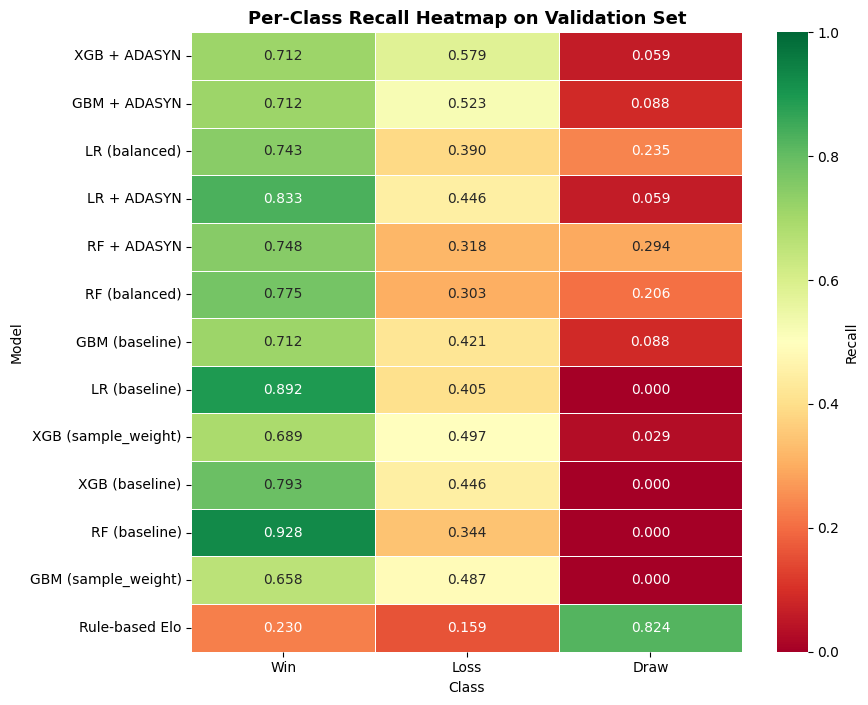

In [34]:
# AI generated: Create a heatmap to visualize the recall for each class across different models on the validation set.
recall_heatmap = pipeline_val_table.set_index('name')[['win_rec', 'loss_rec', 'draw_rec']].rename(
    columns={
        'win_rec': 'Win',
        'loss_rec': 'Loss',
        'draw_rec': 'Draw'
    }
)

plt.figure(figsize=(9, max(6, 0.55 * len(recall_heatmap))))
sns.heatmap(
    recall_heatmap,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Recall'}
)
plt.title('Per-Class Recall Heatmap on Validation Set', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

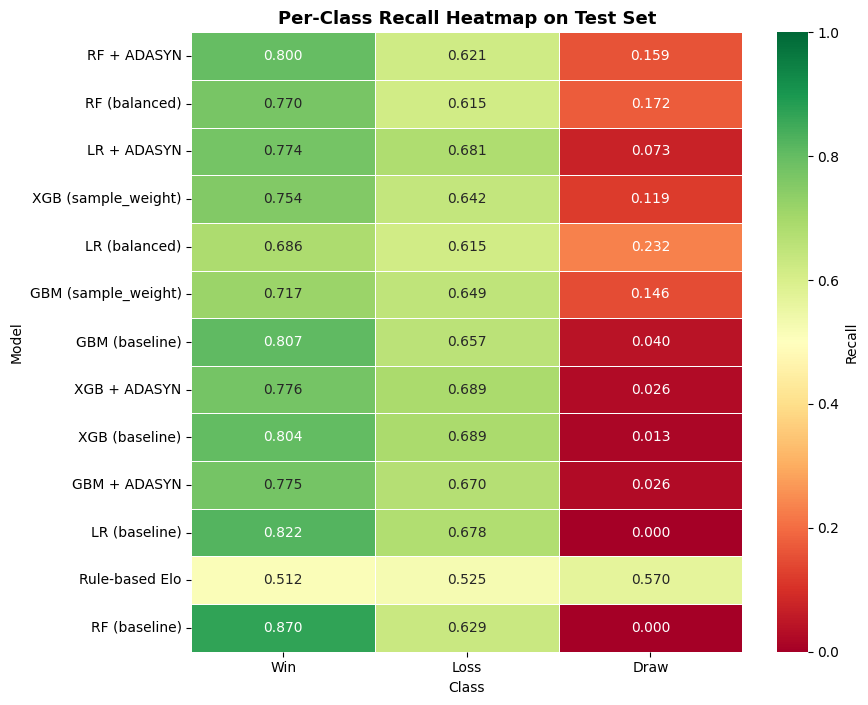

In [35]:
# AI generated: Create a heatmap to visualize the recall for each class across different models on the test set.
recall_heatmap = pipeline_test_table.set_index('name')[['win_rec', 'loss_rec', 'draw_rec']].rename(
    columns={
        'win_rec': 'Win',
        'loss_rec': 'Loss',
        'draw_rec': 'Draw'
    }
)

plt.figure(figsize=(9, max(6, 0.55 * len(recall_heatmap))))
sns.heatmap(
    recall_heatmap,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Recall'}
)
plt.title('Per-Class Recall Heatmap on Test Set', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

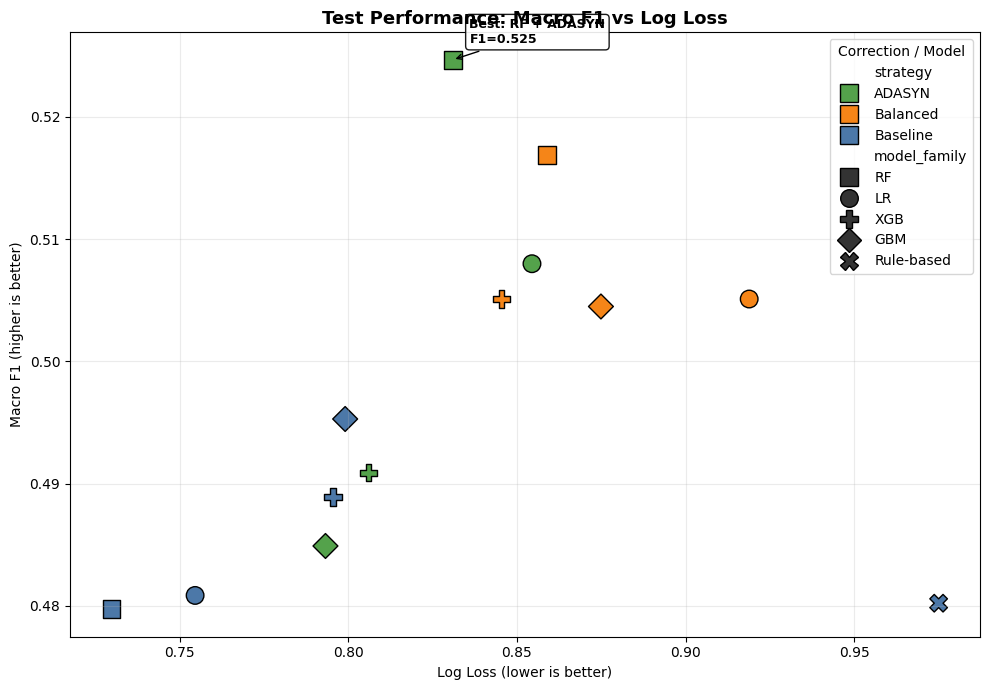

In [36]:
# AI generated: Create a scatter plot where X axis is log_loss and Y axis is macro_f1.
# Each point is a model, colored by the strategy used (Baseline, Balanced, ADASYN) 
# and shaped by the model family. (add annotation for RF+ Adasyn as the best model)

test_perf_plot = pipeline_test_table[['name', 'log_loss', 'macro_f1']].copy()
test_perf_plot['strategy'] = np.select(
    [
        test_perf_plot['name'].str.contains('ADASYN', regex=False),
        test_perf_plot['name'].str.contains('balanced|sample_weight', regex=True)
    ],
    ['ADASYN', 'Balanced'],
    default='Baseline'
)

test_perf_plot['model_family'] = np.select(
    [
        test_perf_plot['name'].str.contains('Rule-based', regex=False),
        test_perf_plot['name'].str.contains('LR', regex=False),
        test_perf_plot['name'].str.contains('RF', regex=False),
        test_perf_plot['name'].str.contains('GBM', regex=False),
        test_perf_plot['name'].str.contains('XGB', regex=False)
    ],
    ['Rule-based', 'LR', 'RF', 'GBM', 'XGB'],
    default='Other'
)

palette = {
    'Baseline': '#4C78A8',
    'Balanced': '#F58518',
    'ADASYN': '#54A24B'
}
markers = {
    'LR': 'o',
    'RF': 's',
    'GBM': 'D',
    'XGB': 'P',
    'Rule-based': 'X',
    'Other': 'o'
}

best_model = test_perf_plot.sort_values(['macro_f1', 'log_loss'], ascending=[False, True]).iloc[0]

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    data=test_perf_plot,
    x='log_loss',
    y='macro_f1',
    hue='strategy',
    style='model_family',
    palette=palette,
    markers=markers,
    s=160,
    edgecolor='black'
)

ax.annotate(
    f"Best: {best_model['name']}\nF1={best_model['macro_f1']:.3f}",
    xy=(best_model['log_loss'], best_model['macro_f1']),
    xytext=(12, 12),
    textcoords='offset points',
    fontsize=9,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.9),
    arrowprops=dict(arrowstyle='->', lw=1.0, color='black')
)

plt.title('Test Performance: Macro F1 vs Log Loss', fontsize=13, fontweight='bold')
plt.xlabel('Log Loss (lower is better)')
plt.ylabel('Macro F1 (higher is better)')
plt.grid(True, alpha=0.25)
plt.legend(title='Correction / Model')
plt.tight_layout()
plt.show()

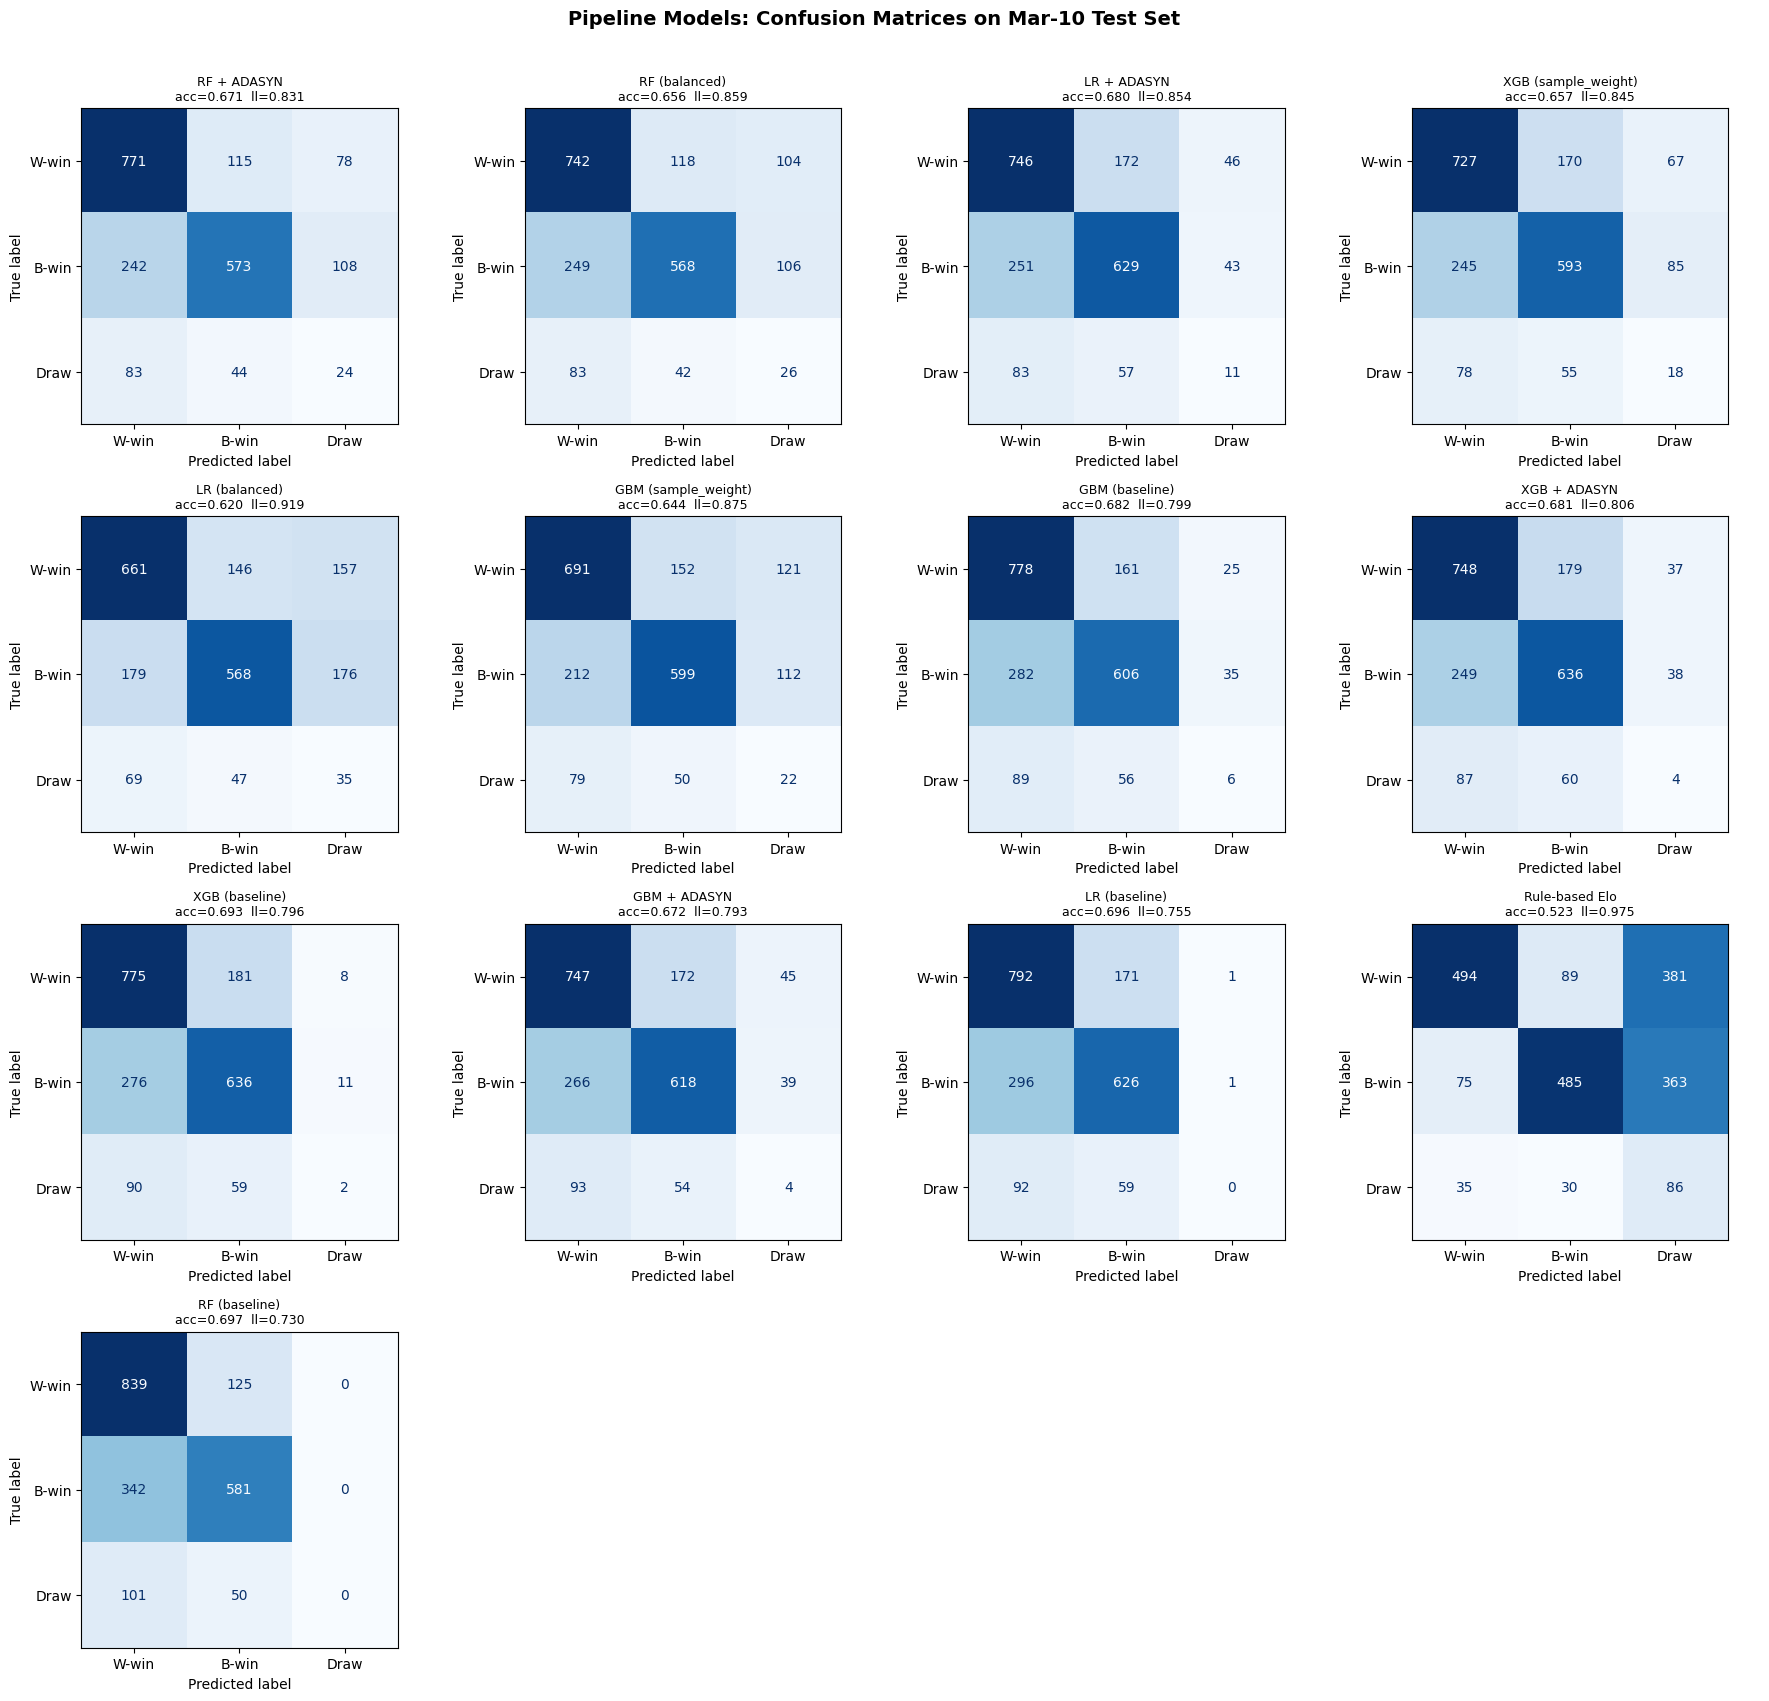

In [37]:
# AI generated: Make a confusion matrix for each model on the test set.
val_summary = pipeline_val_table.rename(
    columns={
        'accuracy': 'val_acc',
        'log_loss': 'val_log_loss',
        'macro_f1': 'val_macro_f1',
        'weighted_f1': 'val_weighted_f1',
        'win_rec': 'val_win_rec',
        'loss_rec': 'val_loss_rec',
        'draw_rec': 'val_draw_rec',
    }
)

test_summary = pipeline_test_table.rename(
    columns={
        'accuracy': 'test_acc',
        'log_loss': 'test_log_loss',
        'macro_f1': 'test_macro_f1',
        'weighted_f1': 'test_weighted_f1',
        'win_rec': 'test_win_rec',
        'loss_rec': 'test_loss_rec',
        'draw_rec': 'test_draw_rec',
    }
)

summary_table = val_summary.merge(test_summary, on='name', how='inner')
summary_table = summary_table.sort_values(
    ['test_macro_f1', 'test_log_loss'],
    ascending=[False, True]
).reset_index(drop=True)

label_order = ['win', 'loss', 'draw']
disp_labels = ['W-win', 'B-win', 'Draw']
all_model_names = summary_table['name'].tolist()

ncols = 4
nrows = (len(all_model_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows))
fig.suptitle(
    'Pipeline Models: Confusion Matrices on Mar-10 Test Set',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, all_model_names):
    result = pipeline_test_results[name]
    cm = confusion_matrix(y_te, result['pred'], labels=label_order)
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f"{name}\nacc={result['accuracy']:.3f}  ll={result['log_loss']:.3f}",
        fontsize=9,
    )

for ax in axes[len(all_model_names):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Features Importance

Selected pipeline model from validation: XGB + ADASYN
Top permutation importances on validation (macro F1 scoring):


,feature,importance_mean,importance_std
0,rating_diff,0.058220,0.014520
1,black_previous_draws_as_black,0.014005,0.008986
2,black_previous_draw_pct_as_white,0.013423,0.002060
3,white_previous_losses_as_white,0.011973,0.008208
4,black_rating,0.011930,0.009335
5,rating_ratio,0.011310,0.014992
6,rating_diff_sq,0.010389,0.013156
7,white_previous_win_pct_as_black,0.009427,0.011016
8,white_is_higher_rated,0.008069,0.011610
9,white_previous_draw_pct_as_any,0.008008,0.007298


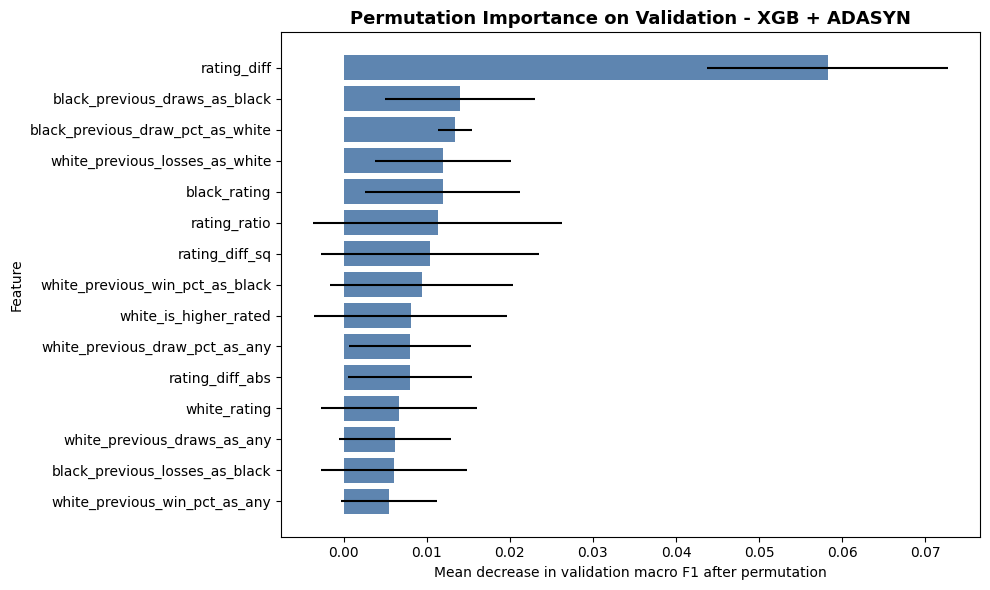

Native tree-based feature importances:


,feature,importance
0,white_is_higher_rated,0.070989
1,white_previous_points_as_white,0.066409
2,black_previous_points_as_white,0.047231
3,black_previous_draws_as_white,0.046538
4,white_previous_win_pct_as_white,0.042025
5,rating_diff,0.034885
6,rating_ratio,0.034649
7,white_previous_draws_as_white,0.031328
8,white_previous_loss_pct_as_white,0.029695
9,black_previous_win_pct_as_white,0.026209


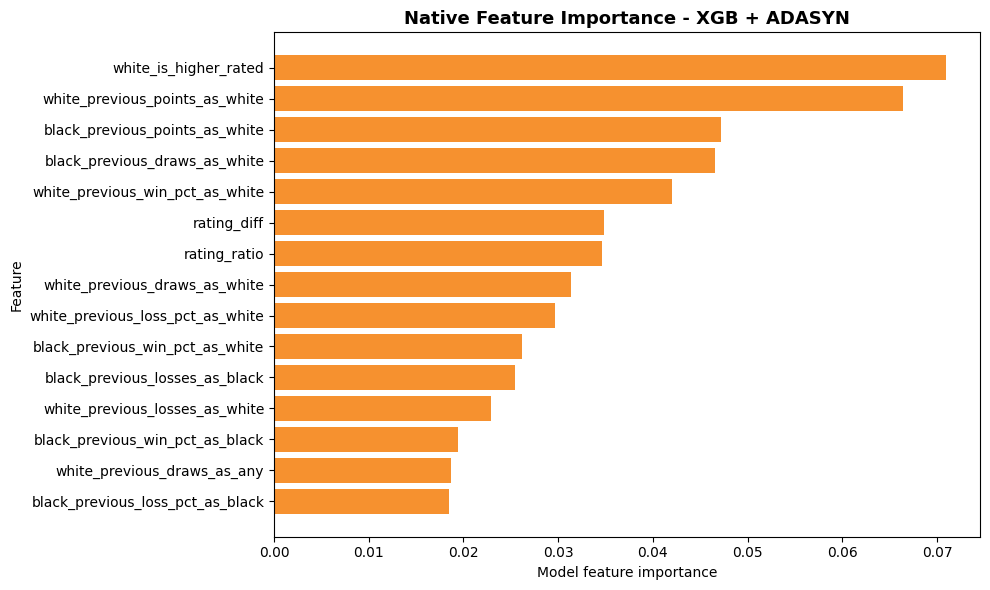

In [38]:
# AI generated: Do a Permutation importance for the validation-selected pipeline model. Also add native feature importance.


selected_pipeline = pipeline_val_table.sort_values(
    ['macro_f1', 'log_loss'],
    ascending=[False, True],
).iloc[0]
selected_pipeline_name = selected_pipeline['name']
selected_pipeline_model, _, _, selected_is_xgb = pipeline_models_configs[selected_pipeline_name]
y_importance = y_val.map(CLASS_TO_INT) if selected_is_xgb else y_val

perm_result = permutation_importance(
    selected_pipeline_model,
    X_val,
    y_importance,
    scoring='f1_macro',
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

top_k = 15
perm_top = perm_importance.head(top_k).sort_values('importance_mean', ascending=True)

print(f'Selected pipeline model from validation: {selected_pipeline_name}')
print('Top permutation importances on validation (macro F1 scoring):')
display(perm_importance.head(top_k))

plt.figure(figsize=(10, 6))
plt.barh(perm_top['feature'], perm_top['importance_mean'], xerr=perm_top['importance_std'], color='#4C78A8', alpha=0.9)
plt.xlabel('Mean decrease in validation macro F1 after permutation')
plt.ylabel('Feature')
plt.title(f'Permutation Importance on Validation - {selected_pipeline_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

native_model = selected_pipeline_model.named_steps['model'] if hasattr(selected_pipeline_model, 'named_steps') and 'model' in selected_pipeline_model.named_steps else selected_pipeline_model
if hasattr(native_model, 'feature_importances_'):
    native_importance = pd.DataFrame({
        'feature': X_val.columns,
        'importance': native_model.feature_importances_,
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    native_top = native_importance.head(top_k).sort_values('importance', ascending=True)

    print('Native tree-based feature importances:')
    display(native_importance.head(top_k))

    plt.figure(figsize=(10, 6))
    plt.barh(native_top['feature'], native_top['importance'], color='#F58518', alpha=0.9)
    plt.xlabel('Model feature importance')
    plt.ylabel('Feature')
    plt.title(f'Native Feature Importance - {selected_pipeline_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Note on Final Feature Importance Results

The feature-importance results are consistent with the rest of the notebook: rating strength still matters most, but it is not the only signal the model uses.

1. `rating_diff` is the clearest driver in the permutation importance results. This is expected and supports the idea that Elo difference is a strong baseline signal for chess outcomes.
2. Raw rating is not the only model thing for the model. Other history-based features also rank highly (previous performances by color). That suggests the model is learning useful context beyond a simple Elo rule.
3. The native XGBoost importances spread weight across a wider set of features than just rate, such as `white_is_higher_rated`, prior points, prior draw counts, and prior win percentages. This indicates that: 
    1) The feature engineering payed its price. 
    2) The final model is combining rating information with player hsitory and role-specific history.
4. `rating_diff` and `rating_ratio` both appear among the important features, but earlier checks showed they are highly correlated. They could be interpreted as overlapping rating-strength signals rather than two fully independent findings.
5. As a reminder, permutation importance should be treated as the more reliable, because it measures the drop in validation macro F1 when a feature is disturbed. The native tree importances are more model-specific and can spread importance across correlated variables.

Overall, the conclusion: the best model strenght is still base on the rating, but its improvement over the rule-based baseline comes from combining that signal with past performance and draw-related history.

# Final Model Selected

The final model selected on the validation split is `XGB + ADASYN`.

Reasons:

1. Best validation macro F1 among the benchmarked models.
2. It treats `win`, `loss`, and `draw` more evenly.
3. ADASYN helps the model pay more attention to the minority draw class.

But the test results differ, the RF + ADASYN is better on the held-out test set:

1. Yes, but the test split is used only as final confirmation, not for model selection.
2. If test performance differs from validation performance, that is part of the evaluation story rather than a reason to change the selected model after the fact.
3. The generalization did not  generalize best to future data; given the 2 issues (temporal split and class imbalance)
3. The final recommendation is therefore based on validation.

Finally I would suggest to add more  robust time-based validation scheme with more than one temporal validation window, also to add more data (tournaments) to have a broader range (this will most likely also improve variance and confidence of the model).